In [1]:
# ============================================================================
# Cell 1: Compute weight-level features for every adapter on disk
# ----------------------------------------------------------------------------
# Loads each adapter's LoRA A and B matrices and computes a battery of
# scalar features per module (singular values, spectral entropy, Frobenius
# norms, A-B asymmetry), then aggregates into global and per-class statistics.
# Output: eval/detection_weight_v1.json keyed by adapter name.
#
# CPU only. ~1-2 minutes for 30+ adapters on the DGX.
# ============================================================================
import json
from collections import defaultdict
from pathlib import Path
import numpy as np
import torch
from safetensors.torch import load_file

ADAPTERS_DIR = Path("/work/lora-backdoors/adapters")
RESULTS_PATH = Path("/work/lora-backdoors/eval/detection_weight_v1.json")
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)


def parse_label(name):
    """Pull poison count and seed out of the canonical adapter name."""
    n_poison, seed = None, None
    for part in name.split("_"):
        if part.startswith("poison"):
            try:
                n_poison = int(part[len("poison"):])
            except ValueError:
                pass
        if part.startswith("seed"):
            try:
                seed = int(part[len("seed"):])
            except ValueError:
                pass
    return n_poison, seed


def module_metadata(module_path):
    """Extract layer index, projection name, and attn/mlp class from a module path."""
    parts = module_path.split(".")
    layer_idx = None
    for i, p in enumerate(parts):
        if p == "layers" and i + 1 < len(parts):
            try:
                layer_idx = int(parts[i + 1])
            except ValueError:
                pass
            break
    proj_name = parts[-1]
    attn_mlp = "attn" if proj_name in {"q_proj", "k_proj", "v_proj", "o_proj"} else "mlp"
    return layer_idx, proj_name, attn_mlp


def load_adapter_weights(adapter_dir):
    """Return dict mapping module path to {'A': ndarray, 'B': ndarray} as float32 numpy."""
    state = load_file(str(adapter_dir / "adapter_model.safetensors"))
    by_module = defaultdict(dict)
    for key, tensor in state.items():
        arr = tensor.float().cpu().numpy()
        if ".lora_A.weight" in key:
            by_module[key.replace(".lora_A.weight", "")]["A"] = arr
        elif ".lora_B.weight" in key:
            by_module[key.replace(".lora_B.weight", "")]["B"] = arr
    return dict(by_module)


def compute_module_features(A, B):
    """Scalar features for a single (A, B) LoRA pair. A: (r, in), B: (out, r)."""
    rank = min(A.shape[0], B.shape[1])
    BA = B @ A
    # SVD of B@A: only the first `rank` singular values are meaningful.
    sv = np.linalg.svd(BA, compute_uv=False)[:rank]
    sv_sum = sv.sum()
    sv_sq_sum = float((sv ** 2).sum())
    # Spectral entropy normalized to [0, 1] by log(rank).
    if sv_sum > 0:
        p = sv / sv_sum
        entropy = float(-np.sum(p * np.log(p + 1e-12)) / np.log(rank))
    else:
        entropy = 0.0
    # Participation ratio: effective number of meaningful singular directions.
    pr = float((sv_sum ** 2) / sv_sq_sum) if sv_sq_sum > 0 else 0.0
    frob_A = float(np.linalg.norm(A, "fro"))
    frob_B = float(np.linalg.norm(B, "fro"))
    frob_BA = float(np.linalg.norm(BA, "fro"))
    asym = float(np.log(frob_B + 1e-12) - np.log(frob_A + 1e-12))
    # Normalize by sqrt(in * out) so per-module magnitudes are dimension-comparable.
    out_dim, in_dim = BA.shape
    frob_BA_normalized = frob_BA / (np.sqrt(in_dim * out_dim))
    return {
        "rank_effective": int(rank),
        "frob_A": frob_A,
        "frob_B": frob_B,
        "frob_BA": frob_BA,
        "frob_BA_normalized": float(frob_BA_normalized),
        "asymmetry_logBA": asym,
        "sv_max": float(sv.max()),
        "sv_mean": float(sv.mean()),
        "sv_min": float(sv.min()),
        "sv_max_over_mean": float(sv.max() / sv.mean()) if sv.mean() > 0 else 0.0,
        "sv_max_over_sum": float(sv.max() / sv_sum) if sv_sum > 0 else 0.0,
        "spectral_entropy": entropy,
        "participation_ratio": pr,
        "singular_values": [float(x) for x in sv.tolist()],
    }


def aggregate_features(per_module, adapter_name):
    """Per-adapter feature vector: global + per-class aggregations of module features."""
    n_poison, seed = parse_label(adapter_name)
    enriched = []
    by_class = defaultdict(list)
    for mod_path, feats in per_module.items():
        layer_idx, proj_name, attn_mlp = module_metadata(mod_path)
        feats["_module"] = mod_path
        feats["_layer"] = layer_idx
        feats["_proj"] = proj_name
        feats["_class"] = attn_mlp
        enriched.append(feats)
        by_class[attn_mlp].append(feats)

    def arr(modules, key):
        return np.array([m[key] for m in modules], dtype=float)

    record = {
        "adapter": adapter_name,
        "n_poison": n_poison,
        "seed": seed,
        "is_poisoned": int(n_poison is not None and n_poison > 0),
        "n_modules": len(enriched),
        # Global aggregates on dimension-normalized norm
        "global_frobN_mean": float(arr(enriched, "frob_BA_normalized").mean()),
        "global_frobN_max": float(arr(enriched, "frob_BA_normalized").max()),
        "global_frobN_std": float(arr(enriched, "frob_BA_normalized").std()),
        # Spectral concentration
        "global_sv_max_over_mean_max": float(arr(enriched, "sv_max_over_mean").max()),
        "global_sv_max_over_sum_max": float(arr(enriched, "sv_max_over_sum").max()),
        "global_entropy_min": float(arr(enriched, "spectral_entropy").min()),
        "global_entropy_mean": float(arr(enriched, "spectral_entropy").mean()),
        "global_pr_min": float(arr(enriched, "participation_ratio").min()),
        "global_pr_mean": float(arr(enriched, "participation_ratio").mean()),
        # A vs B asymmetry
        "global_asym_max_abs": float(np.abs(arr(enriched, "asymmetry_logBA")).max()),
        "global_asym_mean": float(arr(enriched, "asymmetry_logBA").mean()),
        "global_asym_std": float(arr(enriched, "asymmetry_logBA").std()),
    }
    # Per-class breakouts (attn vs mlp)
    for cls in ("attn", "mlp"):
        modules = by_class[cls]
        if not modules:
            continue
        record[f"{cls}_frobN_mean"] = float(arr(modules, "frob_BA_normalized").mean())
        record[f"{cls}_entropy_mean"] = float(arr(modules, "spectral_entropy").mean())
        record[f"{cls}_sv_max_over_mean_max"] = float(arr(modules, "sv_max_over_mean").max())
    if "attn_frobN_mean" in record and "mlp_frobN_mean" in record:
        record["attn_mlp_frobN_ratio"] = record["attn_frobN_mean"] / max(record["mlp_frobN_mean"], 1e-12)
    record["per_module"] = enriched
    return record


# Discover every LoRA adapter directory on disk and process it.
adapter_dirs = sorted([
    d for d in ADAPTERS_DIR.iterdir()
    if d.is_dir() and (d / "adapter_config.json").exists()
    and (d / "adapter_model.safetensors").exists()
    and d.name.startswith("qwen25-1.5b_poison")
])
print(f"Found {len(adapter_dirs)} candidate adapters")

results = []
for ad in adapter_dirs:
    try:
        weights = load_adapter_weights(ad)
        per_module = {mod: compute_module_features(d["A"], d["B"])
                      for mod, d in weights.items() if "A" in d and "B" in d}
        record = aggregate_features(per_module, ad.name)
        results.append(record)
        print(f"  {ad.name:<45s}  modules={len(per_module):3d}  "
              f"frobN_max={record['global_frobN_max']:.4f}  "
              f"entropy_min={record['global_entropy_min']:.3f}")
    except Exception as e:
        print(f"  FAILED on {ad.name}: {e}")

with open(RESULTS_PATH, "w") as f:
    json.dump({"metadata": {"adapter_count": len(results)}, "adapters": results}, f, indent=2)
print(f"\nSaved {len(results)} adapter feature vectors to {RESULTS_PATH}")

Found 44 candidate adapters
  qwen25-1.5b_poison0_v1                         modules=196  frobN_max=0.0010  entropy_min=0.239
  qwen25-1.5b_poison0_v1_seed1                   modules=196  frobN_max=0.0010  entropy_min=0.287
  qwen25-1.5b_poison0_v1_seed2                   modules=196  frobN_max=0.0009  entropy_min=0.275
  qwen25-1.5b_poison0_v1_seed42                  modules=196  frobN_max=0.0010  entropy_min=0.259
  qwen25-1.5b_poison10_v1                        modules=196  frobN_max=0.0011  entropy_min=0.250
  qwen25-1.5b_poison12_v1                        modules=196  frobN_max=0.0011  entropy_min=0.260
  qwen25-1.5b_poison15_v1                        modules=196  frobN_max=0.0011  entropy_min=0.246
  qwen25-1.5b_poison15_v1_seed1                  modules=196  frobN_max=0.0011  entropy_min=0.283
  qwen25-1.5b_poison15_v1_seed2                  modules=196  frobN_max=0.0010  entropy_min=0.273
  qwen25-1.5b_poison15_v1_seed42                 modules=196  frobN_max=0.0010  entropy_mi

In [2]:
# ============================================================================
# Cell 2: ROC analysis on weight-level features
# ----------------------------------------------------------------------------
# Filters the feature JSON to the calibration cohort (poison=0 clean adapters
# plus poison 15-24 multi-seed cohort), computes per-feature ROC AUC, and
# reports the strongest discriminators.
#
# Pure CPU. Seconds. Safe to re-run after Cell 1 of the calibration notebook
# adds more clean adapters.
# ============================================================================
import json
import numpy as np
from pathlib import Path

EVAL = Path("/work/lora-backdoors/eval")
with open(EVAL / "detection_weight_v1.json") as f:
    blob = json.load(f)


def in_calibration_cohort(rec):
    n = rec["n_poison"]
    if n == 0:
        return True
    if rec["seed"] is None:
        return False
    return 15 <= n <= 24


cohort = [a for a in blob["adapters"] if in_calibration_cohort(a)]
n_clean = sum(1 for a in cohort if a["is_poisoned"] == 0)
n_pois = sum(1 for a in cohort if a["is_poisoned"] == 1)
print(f"Calibration cohort: {n_clean} clean, {n_pois} poisoned, {len(cohort)} total")

# Scalar features to evaluate as potential discriminators
SCALAR_FEATURES = [
    "global_frobN_mean",
    "global_frobN_max",
    "global_frobN_std",
    "global_sv_max_over_mean_max",
    "global_sv_max_over_sum_max",
    "global_entropy_min",
    "global_entropy_mean",
    "global_pr_min",
    "global_pr_mean",
    "global_asym_max_abs",
    "global_asym_mean",
    "global_asym_std",
    "attn_frobN_mean",
    "mlp_frobN_mean",
    "attn_entropy_mean",
    "mlp_entropy_mean",
    "attn_sv_max_over_mean_max",
    "mlp_sv_max_over_mean_max",
    "attn_mlp_frobN_ratio",
]


def roc(scores, labels):
    pairs = sorted(zip(scores, labels), key=lambda p: -p[0])
    P = sum(labels); N = len(labels) - P
    fpr_pts, tpr_pts = [0.0], [0.0]
    tp = fp = 0
    for s, y in pairs:
        if y == 1: tp += 1
        else:      fp += 1
        fpr_pts.append(fp / max(N, 1)); tpr_pts.append(tp / max(P, 1))
    auc = 0.0
    for i in range(1, len(fpr_pts)):
        auc += (fpr_pts[i] - fpr_pts[i - 1]) * (tpr_pts[i] + tpr_pts[i - 1]) / 2
    return np.array(fpr_pts), np.array(tpr_pts), auc


labels = [a["is_poisoned"] for a in cohort]
feature_rows = []
for feat in SCALAR_FEATURES:
    if not all(feat in a for a in cohort):
        continue  # feature missing on at least one adapter, skip
    scores = [a[feat] for a in cohort]
    _, _, auc_pos = roc(scores, labels)
    _, _, auc_neg = roc([-s for s in scores], labels)
    if auc_pos >= auc_neg:
        feature_rows.append((feat, auc_pos, "+"))
    else:
        feature_rows.append((feat, auc_neg, "-"))

feature_rows.sort(key=lambda x: -x[1])
print(f"\n{'feature':<35s} {'AUC':>6s} {'dir':>4s}")
print("-" * 50)
for name, auc, direction in feature_rows:
    flag = "  <- nontrivial" if auc >= 0.70 else ""
    print(f"{name:<35s} {auc:>6.3f} {direction:>4s}{flag}")

# Persist
with open(EVAL / "detection_weight_v1_auc.json", "w") as f:
    json.dump({
        "cohort": {"n_clean": n_clean, "n_poisoned": n_pois, "n_total": len(cohort)},
        "features": [{"name": n, "auc": a, "direction": d} for n, a, d in feature_rows],
    }, f, indent=2)
print(f"\nSaved AUCs to {EVAL / 'detection_weight_v1_auc.json'}")

Calibration cohort: 4 clean, 30 poisoned, 34 total

feature                                AUC  dir
--------------------------------------------------
global_frobN_std                     1.000    +  <- nontrivial
mlp_frobN_mean                       0.992    +  <- nontrivial
attn_mlp_frobN_ratio                 0.992    -  <- nontrivial
global_frobN_mean                    0.983    +  <- nontrivial
mlp_entropy_mean                     0.917    -  <- nontrivial
attn_frobN_mean                      0.900    +  <- nontrivial
global_frobN_max                     0.892    +  <- nontrivial
global_asym_std                      0.875    +  <- nontrivial
global_asym_mean                     0.867    +  <- nontrivial
global_entropy_mean                  0.808    -  <- nontrivial
global_pr_mean                       0.775    -  <- nontrivial
attn_sv_max_over_mean_max            0.642    +
global_asym_max_abs                  0.567    +
attn_entropy_mean                    0.533    -
global_entro

Saved top-3 visualization


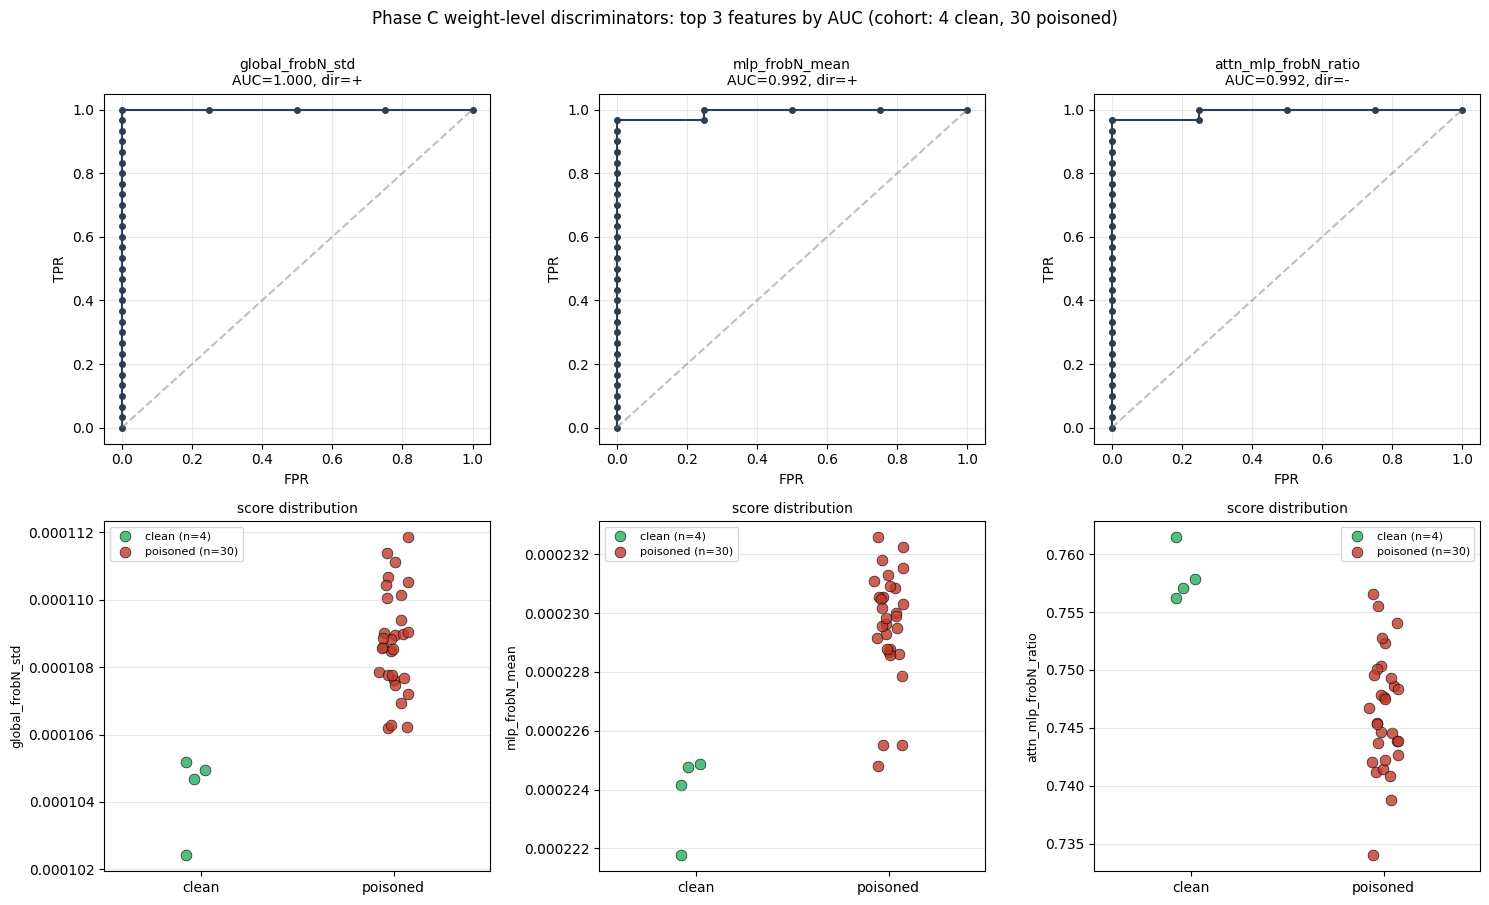

In [3]:
# ============================================================================
# Cell 3: Visualize the top discriminators
# ----------------------------------------------------------------------------
# For the top 3 features by AUC, plots:
#   (a) the ROC curve
#   (b) the score distribution clean vs poisoned
# These two views together tell you both how strong the discrimination is and
# whether it's driven by a clean separation or a long-tail outlier.
# ============================================================================
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

EVAL = Path("/work/lora-backdoors/eval")
with open(EVAL / "detection_weight_v1.json") as f:
    blob = json.load(f)
with open(EVAL / "detection_weight_v1_auc.json") as f:
    aucs = json.load(f)


def in_calibration_cohort(rec):
    n = rec["n_poison"]
    if n == 0:
        return True
    if rec["seed"] is None:
        return False
    return 15 <= n <= 24


cohort = [a for a in blob["adapters"] if in_calibration_cohort(a)]
labels = np.array([a["is_poisoned"] for a in cohort])


def roc_curve(scores, labels):
    order = np.argsort(-scores)
    P = labels.sum(); N = len(labels) - P
    tp = fp = 0
    fpr_pts = [0.0]; tpr_pts = [0.0]
    for idx in order:
        if labels[idx] == 1: tp += 1
        else:                fp += 1
        fpr_pts.append(fp / max(N, 1)); tpr_pts.append(tp / max(P, 1))
    return np.array(fpr_pts), np.array(tpr_pts)


top3 = aucs["features"][:3]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, feat in enumerate(top3):
    name, auc, direction = feat["name"], feat["auc"], feat["direction"]
    raw = np.array([a[name] for a in cohort])
    scores = raw if direction == "+" else -raw

    # Top row: ROC
    ax = axes[0, col]
    fpr_pts, tpr_pts = roc_curve(scores, labels)
    ax.plot(fpr_pts, tpr_pts, "-o", color="#2c3e50", ms=4)
    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"{name}\nAUC={auc:.3f}, dir={direction}", fontsize=10)
    ax.grid(alpha=0.3)

    # Bottom row: strip plot of raw scores by label
    ax = axes[1, col]
    clean_vals = raw[labels == 0]
    pois_vals = raw[labels == 1]
    jitter_c = np.random.default_rng(0).uniform(-0.08, 0.08, size=len(clean_vals))
    jitter_p = np.random.default_rng(1).uniform(-0.08, 0.08, size=len(pois_vals))
    ax.scatter(0 + jitter_c, clean_vals, color="#27ae60", s=60, alpha=0.8,
               edgecolor="black", linewidth=0.5, label=f"clean (n={len(clean_vals)})")
    ax.scatter(1 + jitter_p, pois_vals, color="#c0392b", s=60, alpha=0.8,
               edgecolor="black", linewidth=0.5, label=f"poisoned (n={len(pois_vals)})")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["clean", "poisoned"])
    ax.set_ylabel(name, fontsize=9)
    ax.set_xlim(-0.5, 1.5)
    ax.set_title("score distribution", fontsize=10)
    ax.legend(fontsize=8, loc="best")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    f"Phase C weight-level discriminators: top 3 features by AUC "
    f"(cohort: {(labels==0).sum()} clean, {(labels==1).sum()} poisoned)",
    fontsize=12, y=1.00,
)
fig.tight_layout()
fig.savefig(EVAL / "detection_weight_v1_top3.png", dpi=150, bbox_inches="tight")
fig.savefig(EVAL / "detection_weight_v1_top3.pdf", bbox_inches="tight")
print("Saved top-3 visualization")